Project : Apply a model on data
Goal : Find the best model for each category : ARMA, GARCH, ARMA-GARCH
Data : use openandseedata.py to create the data : data = Norvegian kroner / another currency
I choosed the US dollar

Main steps:
- Create data
- See ACP and PACP graph to estimate ARMA model
- Understand what is GARCH and ARMA_GARCH
- Create models
- Evaluate models

My steps:
- create data
- fill with the mean between the closest values when the data is missing
- Plot ACP and PACP
- Create a First ARIMA model with the first 80% of the data
- Plot the forcast and the real data 


Create data
"XUDLNKD": "Norwegian Kroner" 
"XUDLUSS": "US Dollar"

US / NK
the order is inversed in the data because is is pounds/NOK and pounds/USD

Teacher ARIMA model : (5,3,1)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [4]:
data= pd.read_csv('boe_fx.csv')
data= data.dropna(subset=["XUDLNKD","XUDLUSS"])
print(data["Date"].min())
print(data["Date"].max())
Serie = data["XUDLNKD"]/data["XUDLUSS"]
Dates = pd.to_datetime(data["Date"])

1975-01-02
2025-10-13


In [4]:
def RMSE(truevalues,pred):
    truevalues=np.array(truevalues)
    pred=np.array(pred)
    return np.sqrt(np.mean((truevalues-pred)**2))

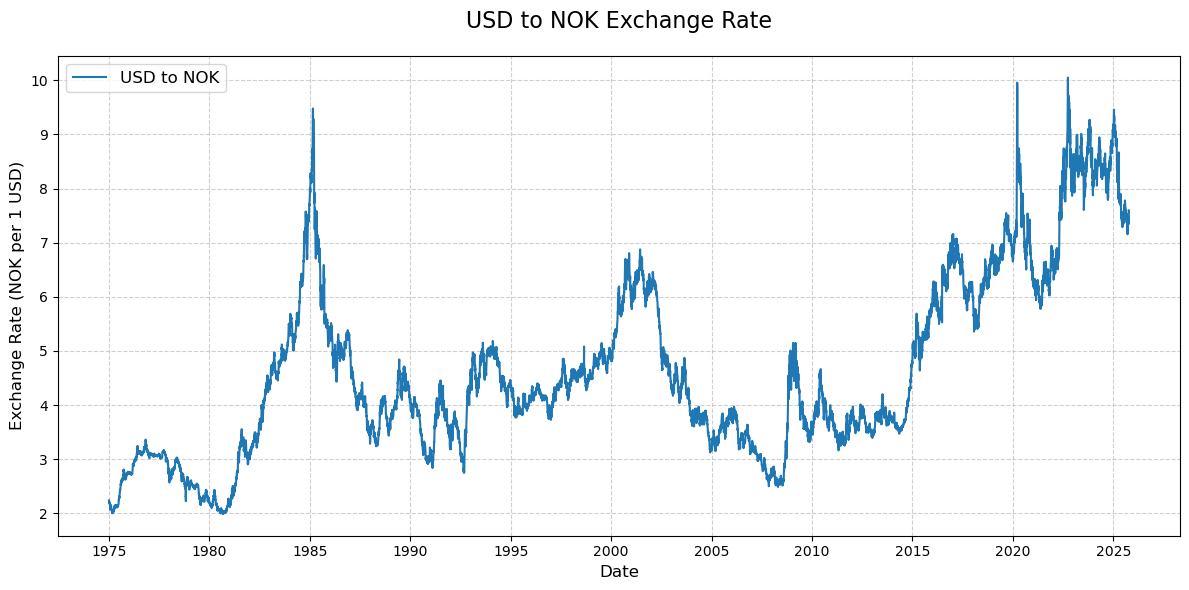

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Assuming Dates is a datetime object and Serie is numeric
plt.figure(figsize=(12, 6))  # Wider figure for better readability

# Plot the data
plt.plot(Dates, Serie, color='#1f77b4', markersize=4, label='USD to NOK')

# Customize x-axis for dates

# Add labels and title
plt.title('USD to NOK Exchange Rate', fontsize=16, pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Exchange Rate (NOK per 1 USD)', fontsize=12)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# Adjust layout to prevent clipping
plt.tight_layout()

plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))  # Major ticks every 5 years
# Show the plot
plt.show()


<Figure size 1200x600 with 0 Axes>

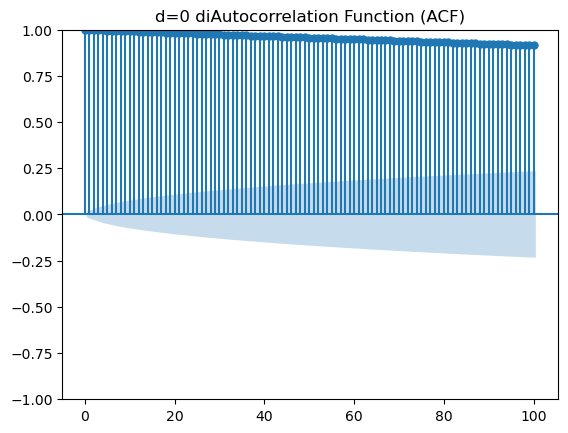

<Figure size 1200x600 with 0 Axes>

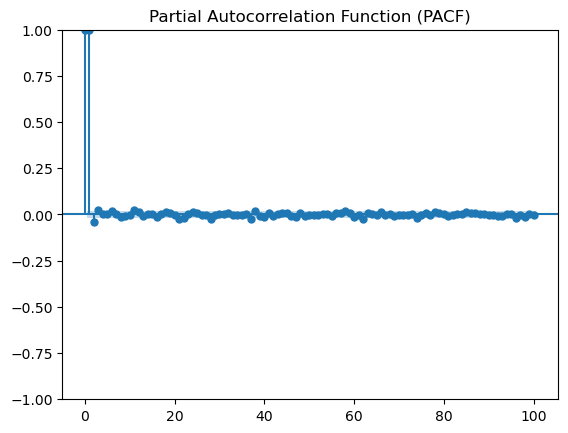

In [5]:
# Plot ACF
diff_series = Serie.dropna()

plt.figure(figsize=(12, 6))
plot_acf(diff_series, lags=100, alpha=0.05)
plt.title('d=0 diAutocorrelation Function (ACF)')
plt.show()

# Plot PACF
plt.figure(figsize=(12, 6))
plot_pacf(diff_series, lags=100, alpha=0.05, method='ywm')
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

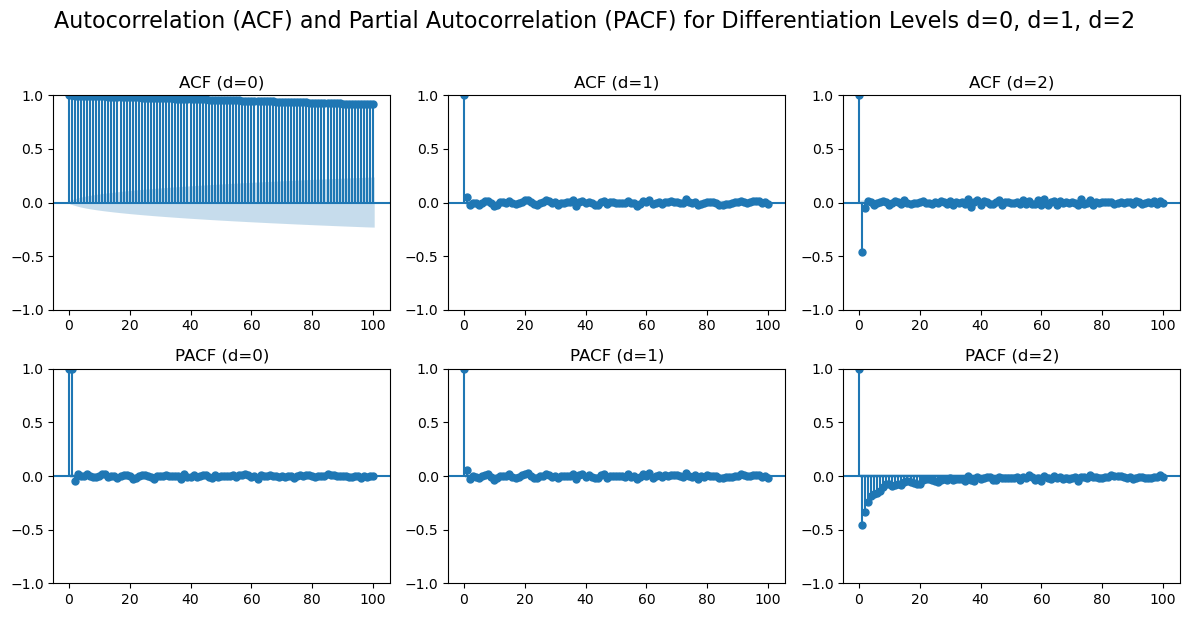

In [15]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Prepare the data for d=0, d=1, d=2
d0 = Serie.dropna()  # Original series
d1 = Serie.diff().dropna()  # First difference
d2 = Serie.diff().diff().dropna()  # Second difference

# Create a 2x3 subplot grid (2 rows for ACF/PACF, 3 columns for d=0,1,2)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))
fig.suptitle('Autocorrelation (ACF) and Partial Autocorrelation (PACF) for Differentiation Levels d=0, d=1, d=2', fontsize=16, y=1.02)

# Plot ACF for d=0, d=1, d=2
plot_acf(d0, lags=100, alpha=0.05, ax=axes[0, 0])
axes[0, 0].set_title('ACF (d=0)')
plot_acf(d1, lags=100, alpha=0.05, ax=axes[0, 1])
axes[0, 1].set_title('ACF (d=1)')
plot_acf(d2, lags=100, alpha=0.05, ax=axes[0, 2])
axes[0, 2].set_title('ACF (d=2)')

# Plot PACF for d=0, d=1, d=2
plot_pacf(d0, lags=100, alpha=0.05, method='ywm', ax=axes[1, 0])
axes[1, 0].set_title('PACF (d=0)')
plot_pacf(d1, lags=100, alpha=0.05, method='ywm', ax=axes[1, 1])
axes[1, 1].set_title('PACF (d=1)')
plot_pacf(d2, lags=100, alpha=0.05, method='ywm', ax=axes[1, 2])
axes[1, 2].set_title('PACF (d=2)')

# Adjust layout
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

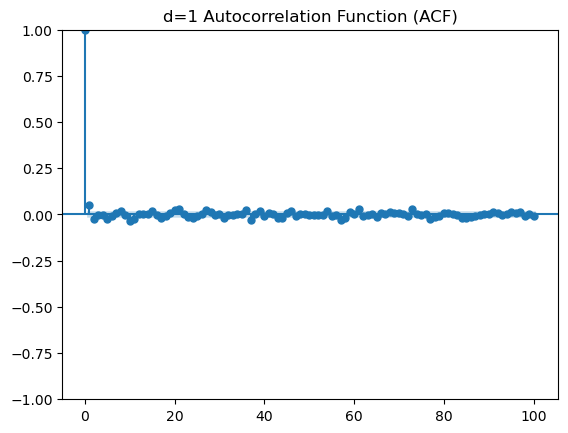

<Figure size 1200x600 with 0 Axes>

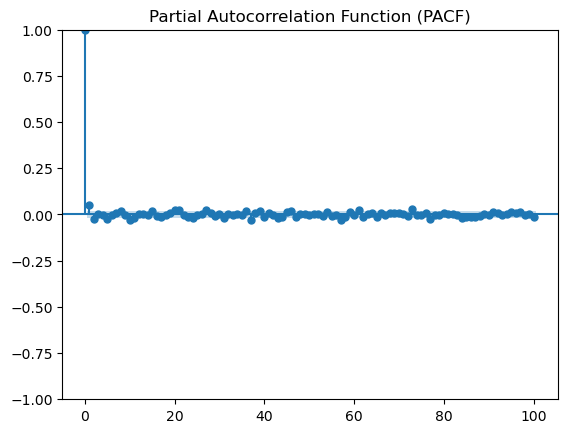

In [6]:
# Plot ACF
diff_series = Serie.diff().dropna()

plt.figure(figsize=(12, 6))
plot_acf(diff_series, lags=100, alpha=0.05)
plt.title('d=1 Autocorrelation Function (ACF)')
plt.show()

# Plot PACF
plt.figure(figsize=(12, 6))
plot_pacf(diff_series, lags=100, alpha=0.05, method='ywm')
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

In [16]:
n_test = 200
train, test = Serie[:-n_test], Serie[-n_test:]
test=test.reset_index(drop=True)

model = ARIMA(train, order=(1,0,1)).fit()


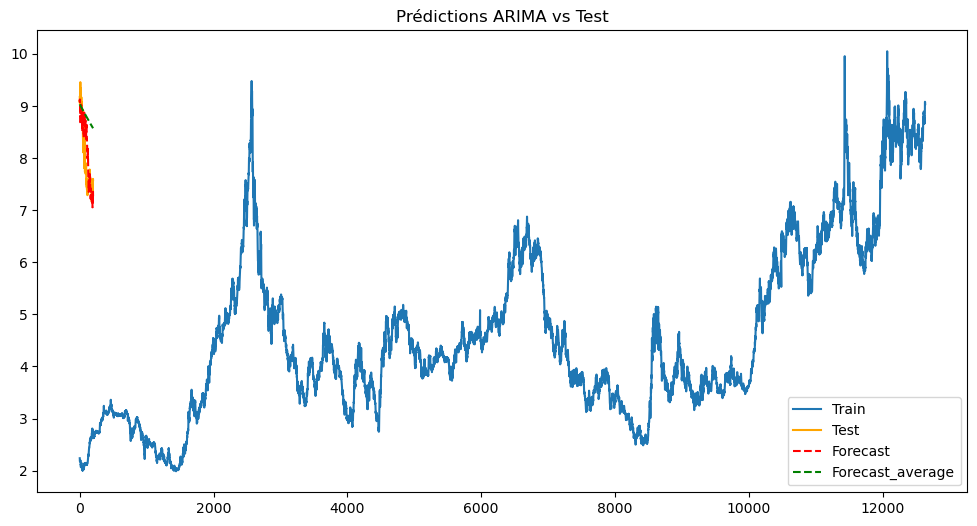

In [17]:
forecast1 = model.simulate(nsimulations=len(test), anchor='end')

forecast2 = model.forecast(steps=len(test))

plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')

# Tracer les prédictions (en alignant les index)
forecast_index = test.index  # On suppose que les index de test suivent ceux de train
plt.plot(forecast_index, forecast1, label='Forecast', color='red', linestyle='--')
plt.plot(forecast_index, forecast2, label='Forecast_average', color='green', linestyle='--')

plt.legend()
plt.title('Prédictions ARIMA vs Test')
plt.show()

In [18]:
predictions = []
history = train.copy()  # Start with the training data
# Rolling forecast
for i in range(len(test)):
    # Predict the next value
    forecast = model.forecast(steps=1)
    predictions.append(forecast.iloc[0])

    # Re-fit the model with the updated history (without re-training parameters)
    # Note: This step updates the model's internal state (lagged values, residuals)
    model = model.append([test.iloc[i]], refit=False)



In [19]:
print(RMSE(test,predictions))


0.08975888191947251


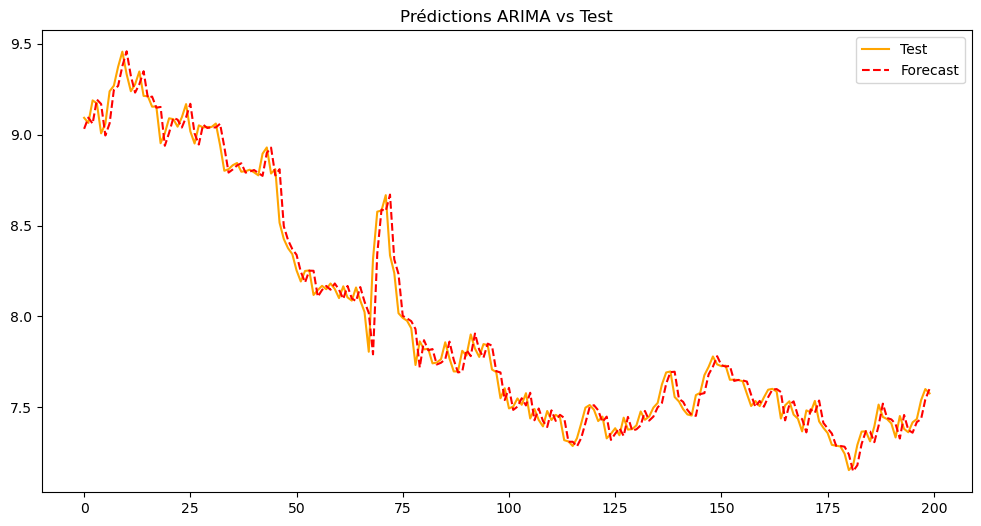

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Test', color='orange')

# Tracer les prédictions (en alignant les index)
forecast_index = test.index  # On suppose que les index de test suivent ceux de train
plt.plot(forecast_index, predictions, label='Forecast', color='red', linestyle='--')
plt.legend()
plt.title('Prédictions ARIMA vs Test')
plt.show()

In [21]:
# Lets do the loop to find the best ARIMA model

In [22]:
#Dumb sample

preds = Serie[-(n_test+1):-1]

err = RMSE(test,preds)
print(err)

0.08980172289795922


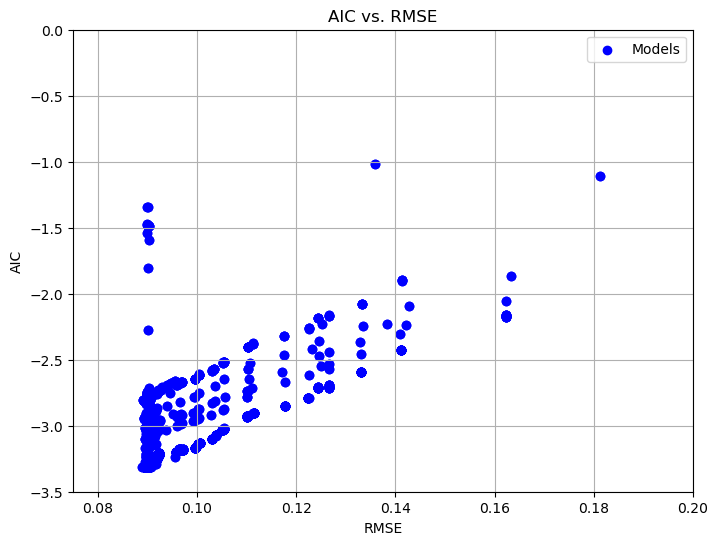

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data from the CSV file
results = pd.read_csv("ARIMA-GARCH-results.csv")

# Create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(results["RMSE"], results["AIC"], color='blue', label='Models')

# Add labels and title
plt.xlabel("RMSE")
plt.ylabel("AIC")
plt.title("AIC vs. RMSE")
plt.xlim(0.075, 0.2)  # RMSE range
plt.ylim(-3.5, 0)  # AIC range
# Optional: Annotate each point with its index
plt.scatter(results["RMSE"], results["AIC"], color='blue')

# Add grid and legend
plt.grid(True)
plt.legend()

# Show the plot
plt.show()


In [19]:
rmse= np.array([0.089382,0.089808, 0.088933])
relative_rmse = (rmse-0.089801)/0.089801 *100
print(relative_rmse)

[-0.46658723  0.00779501 -0.96658166]


In [2]:
results = pd.read_csv("ARIMA-GARCH-results.csv")
print(results["RMSE"].min())
print(results["AIC"].min())

0.0889328607418328
-3.31228712907549


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load and filter*
lrmse=0.09
laic=-3.
results = pd.read_csv("ARIMA-GARCH-results.csv")
results = results[(results["RMSE"] < lrmse) & (results["AIC"] < laic)]

# Create label column
results["label"] = results.apply(
    lambda r: f"({r.da},{r.pa},{r.qa},{r.pg},{r.qg})", axis=1
)

# Plot scatter
plt.figure(figsize=(8, 6))
plt.scatter(results["RMSE"], results["AIC"], color='blue', label='Models')

# Add text labels (no explicit loop)
results.apply(
    lambda r: plt.text(r.RMSE, r.AIC, r.label, fontsize=8, color='darkred', ha='left', va='bottom'),
    axis=1
)

# Axes, grid, legend
plt.xlabel("RMSE")
plt.ylabel("AIC")
plt.title("AIC vs. RMSE (Filtered)")
plt.xlim(0.0889, lrmse)
plt.ylim(-3.312, laic)
plt.grid(True)
plt.legend()
plt.show()



KeyboardInterrupt: 